Here is the production ready notebook.<br>You can find other notebook experimental notebook with same.

Uploading .csv file. Main Data.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Telco-Customer-Churn.csv to Telco-Customer-Churn.csv


All librabries and dependencies.

In [ ]:
!pip install scikit-learn
!pip install pandas
!pip install numpy
!pip install seaborn
!pip install matplotlib
!pip install sklearn

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import make_column_selector

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score

In [ ]:
# Read file & get sample of the data
data = pd.read_csv('Telco-Customer-Churn.csv')
data.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
2188,3689-MOZGR,Female,0,No,No,29,No,No phone service,DSL,No,...,No,Yes,No,No,Month-to-month,Yes,Electronic check,31.20,926.2,No
4520,3506-LCJDC,Male,0,Yes,Yes,1,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Bank transfer (automatic),19.95,19.95,Yes
1229,9068-VPWQQ,Male,0,Yes,No,61,Yes,Yes,DSL,Yes,...,Yes,Yes,No,Yes,Two year,No,Credit card (automatic),75.35,4729.3,No
1277,4821-WQOYN,Female,0,Yes,Yes,72,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Credit card (automatic),20.10,1326.25,No
2446,9492-TOKRI,Female,0,No,No,18,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),90.00,1527.35,Yes


In [ ]:
# No of record and features in the data
data.shape

(7043, 21)

In [ ]:
# Data-Types of the features
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


**Data Preprocessing**

In [ ]:
# Assign Related data types and remove CustomerID
data['SeniorCitizen'] = data['SeniorCitizen'].astype(int)
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
data['TotalCharges'] = data['TotalCharges'].fillna(0)
data.drop(columns = ['customerID'], inplace = True)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [ ]:
# Checking Co-relation between numeric column
numeric_corr = data.select_dtypes(include = ['number']).corr()
numeric_corr

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.016567,0.220173,0.103006
tenure,0.016567,1.000000,0.247900,0.826178
MonthlyCharges,0.220173,0.247900,1.000000,0.651174
TotalCharges,0.103006,0.826178,0.651174,1.000000


**EDA**

<Axes: xlabel='Churn', ylabel='Percent'>

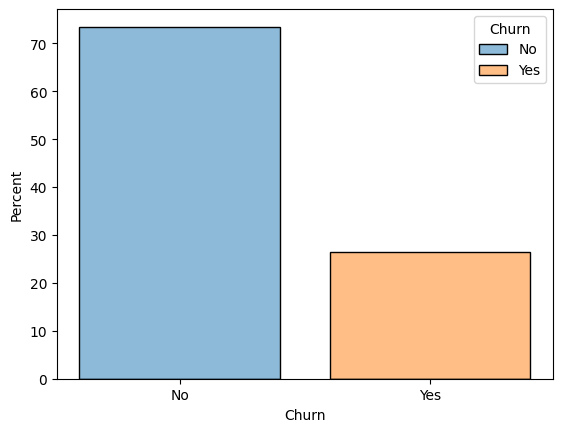

In [ ]:
sns.histplot(x='Churn', stat='percent', shrink = 0.8, hue = 'Churn', data = data)

There is around 25 % people who churned in the data.

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:453: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=figsize)


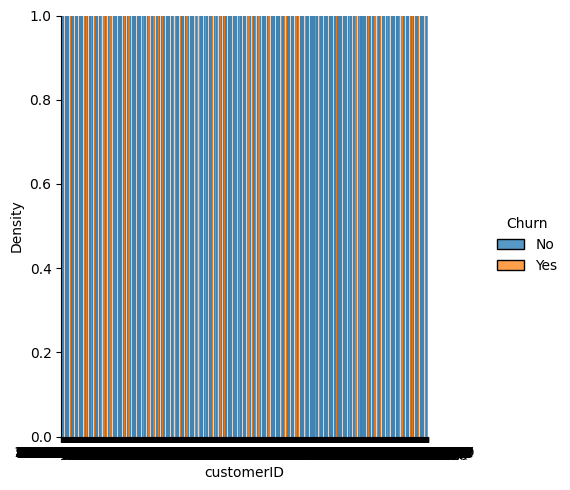

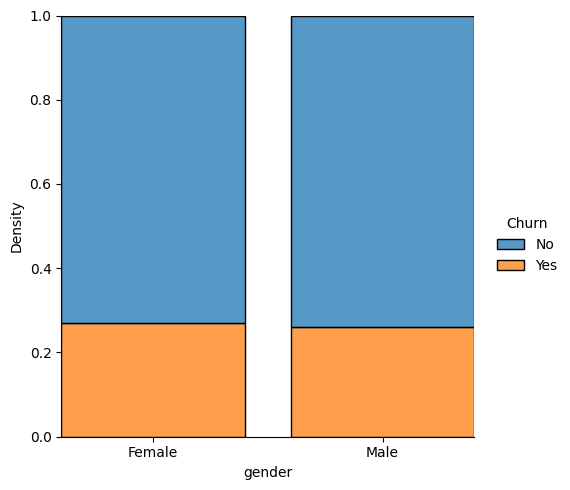

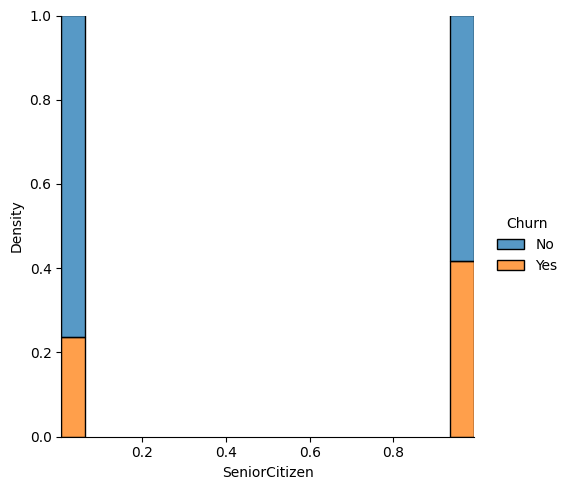

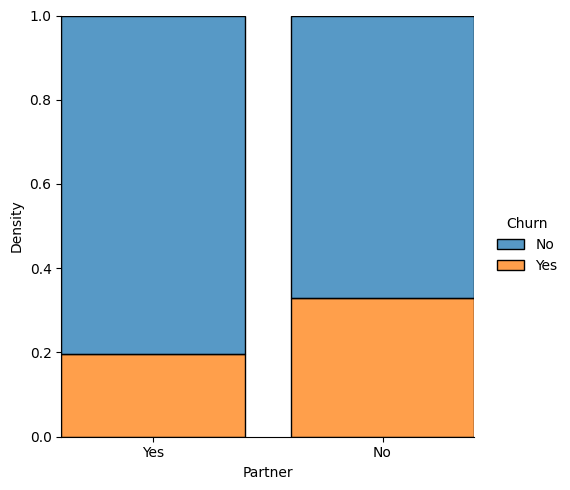

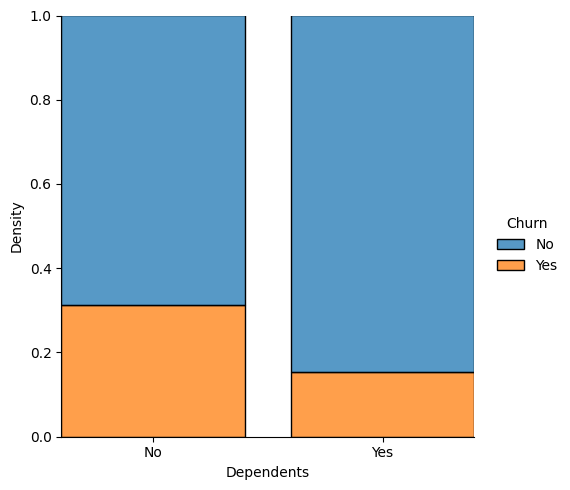

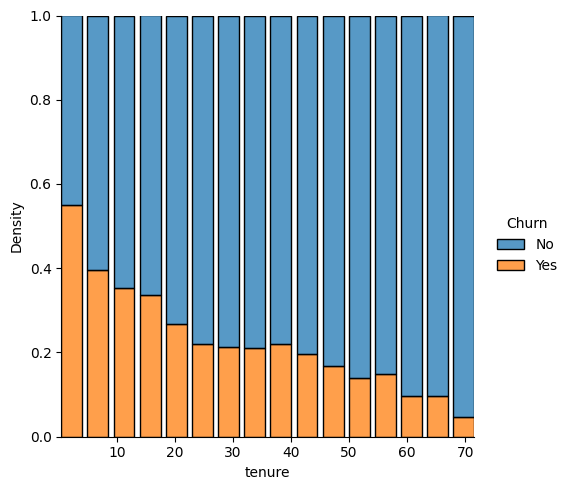

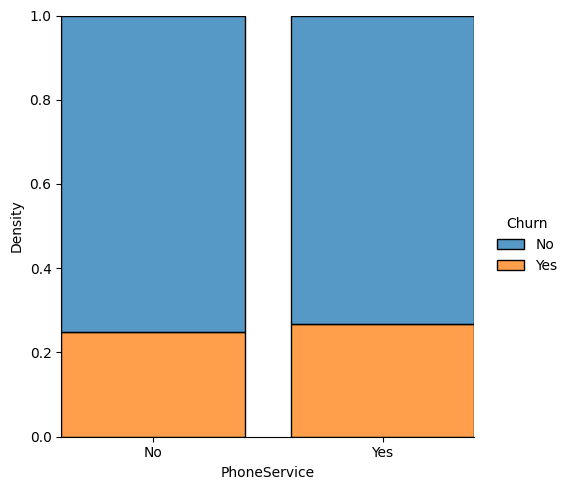

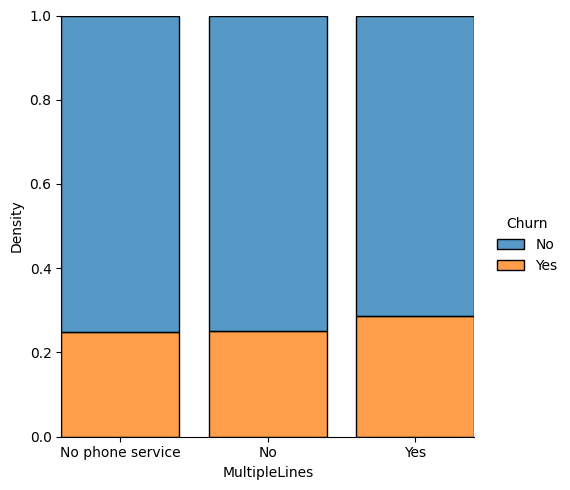

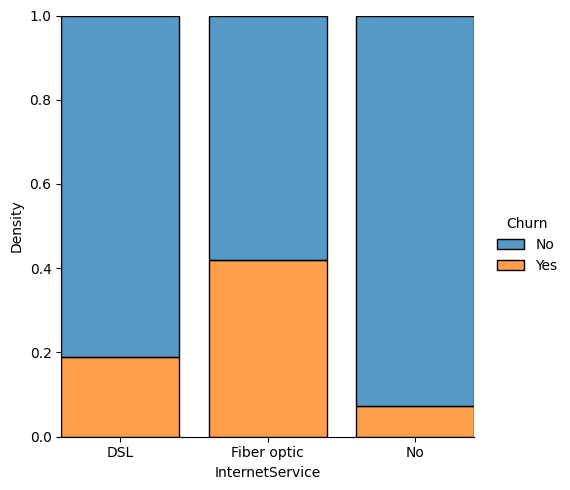

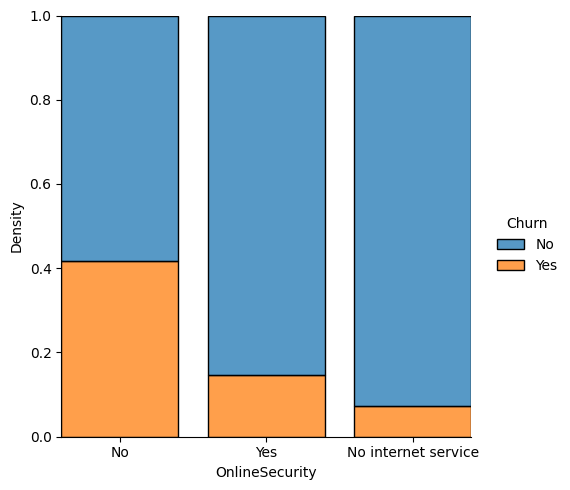

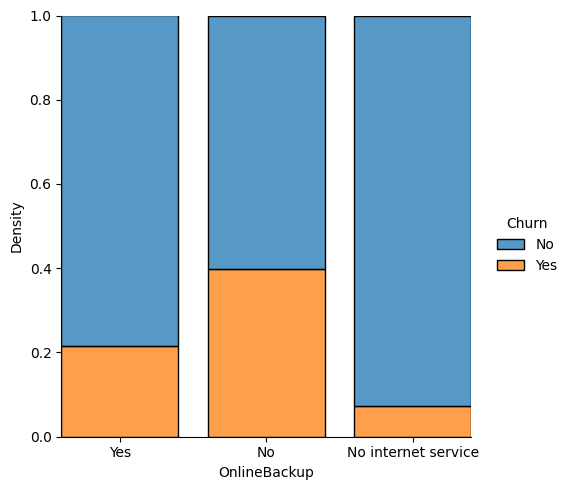

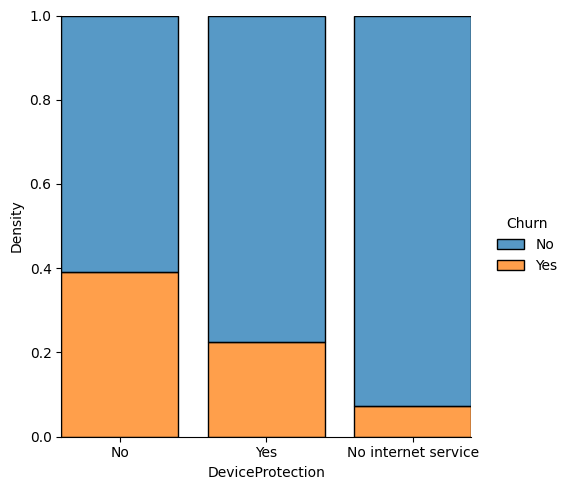

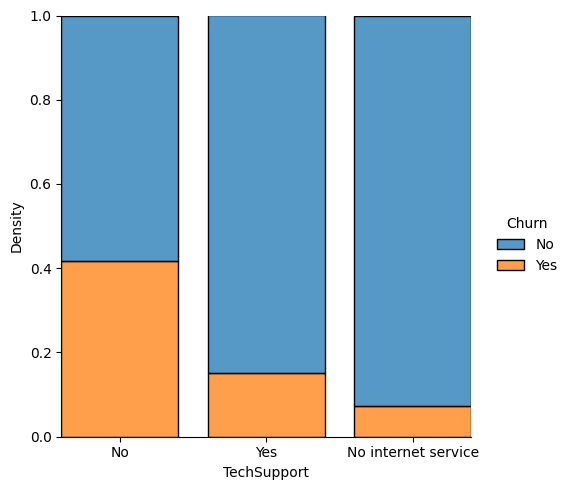

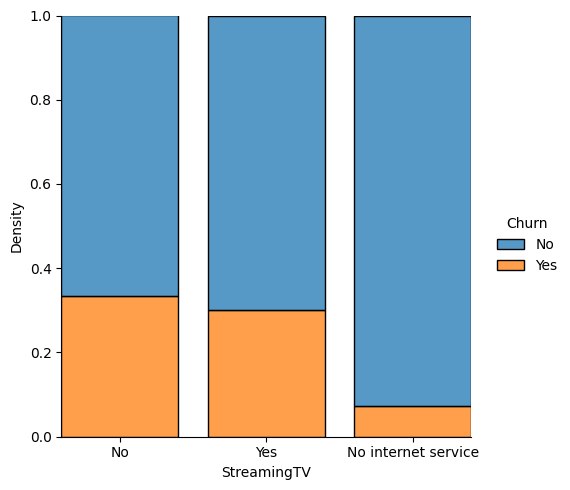

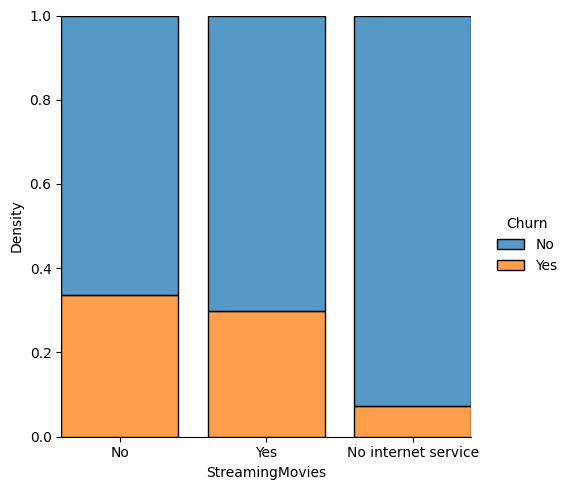

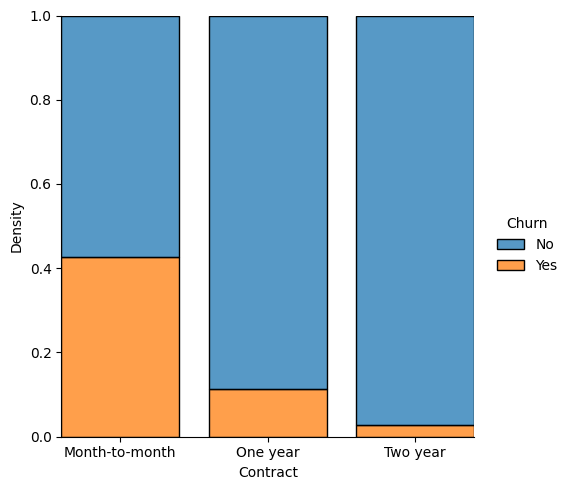

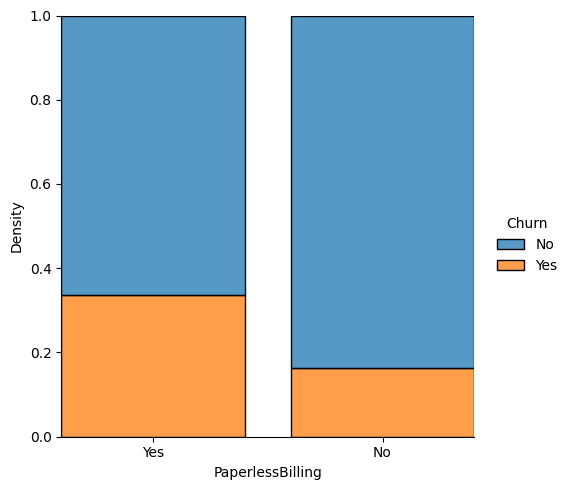

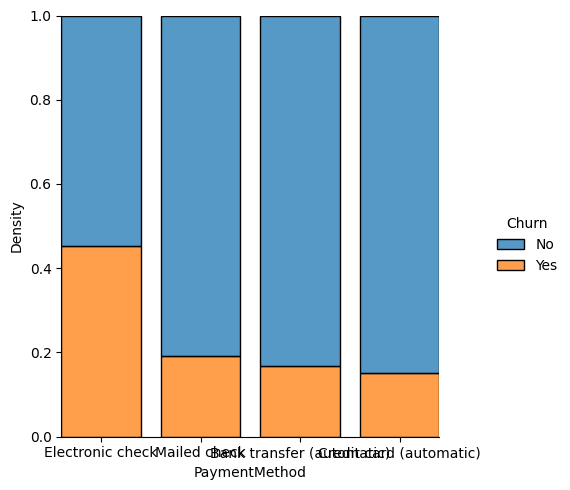

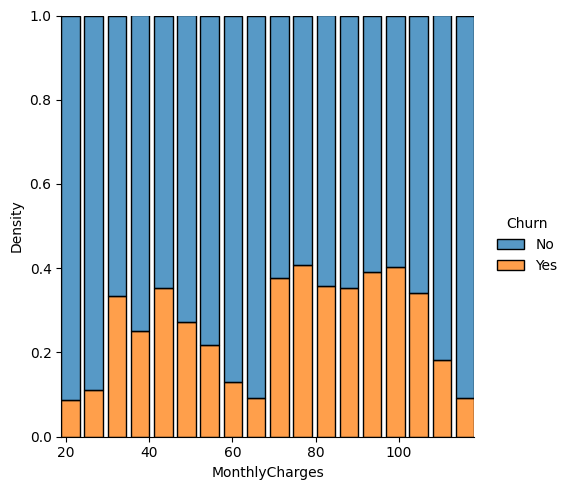

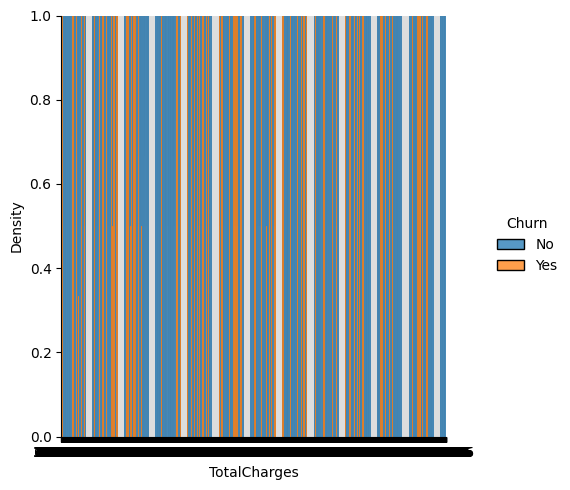

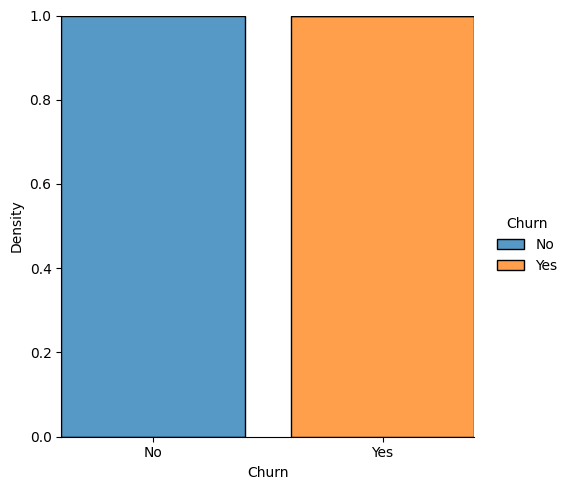

In [ ]:
# Plotting histplot for each column to see the relevance of the feature with churning.

for col in data.columns:
  sns.displot(x=col, stat ='density', hue = 'Churn', multiple = 'fill', shrink = 0.8, data= data)

Conclusion from the graphs.

1. Churn Rate for both gender is same.
2. Churn Rate for Senior Citizen, Non Partener, Non Dependents is High
3. Churn rate is in decreasing way from less tenure to more tenure.
4. For Phone Service it is almost same
5. People using fiber optice for internetservice has hire churn rate.
6. People having NO online security,No online Backup, No device Protection, No tech support have higher churning rate
7. For streaming tv it is almost same
8. People with month - to - month contract have higher churing rate
9. People having paper billing have higher churning rate
10. People paying with electronic check have higher churning rate.

Overall churn rate is varying with
Senior Citizen, Non Parteners, Non Dependents, Tenure, Fibre Optics, Not having facilty of online security, online backup, device protection, tech support and  month - to - month contract having people, paper billing

<Axes: xlabel='Churn', ylabel='tenure'>

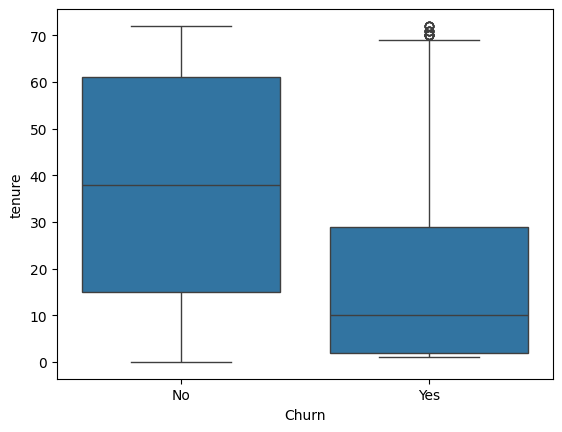

In [ ]:
# Box Plot For Numerical Data to find median behaviors
# 1. With Tenure
sns.boxplot(x= 'Churn', y = 'tenure', data= data)

Median of tenure who is churning is **10 month**

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

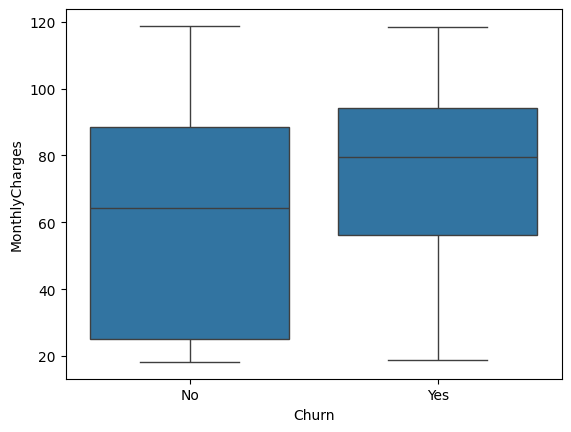

In [ ]:
# 2. with Monthly Charges
sns.boxplot(x= 'Churn', y = 'MonthlyCharges', data= data)

People who churned has median of monthly charges nearly **80**.

**Checking for outliers**

<Axes: ylabel='tenure'>

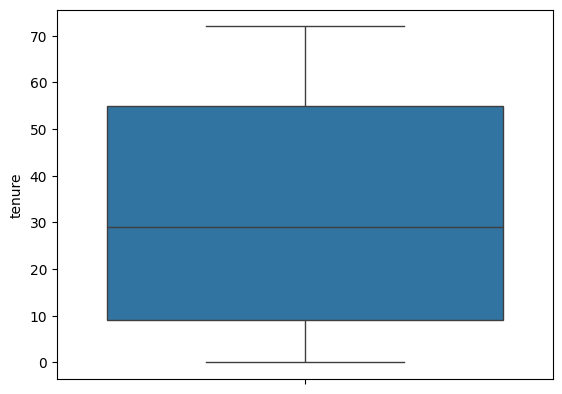

In [ ]:
# Tenure
sns.boxplot(y = 'tenure', data= data)

<Axes: ylabel='TotalCharges'>

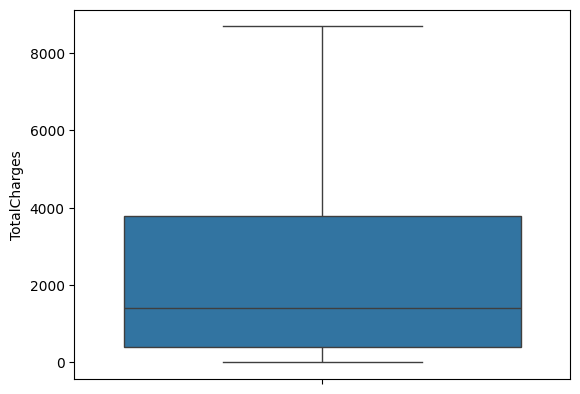

In [ ]:
# For Total Charges
sns.boxplot(y = 'TotalCharges', data= data)

<Axes: ylabel='TotalCharges'>

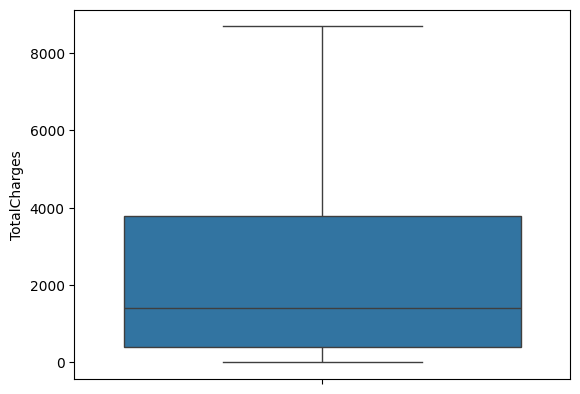

In [ ]:
# For Monthly Charges
sns.boxplot( y = 'TotalCharges', data= data)

No outilers in total.

In [ ]:
# Checking for NaN
data.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


**Feature Engineering**

1. Can preprocess the tenure like binding them into years unit.
2. Can combine 'No', 'No phone service' in the MultipleLines column
3. Same thing for 'No internet service', 'No' in online security, online backup, Device Protection, Tech support, Streaming TV and Movies

In [ ]:
# Processing Tenure
data['tenure'].describe()

,tenure
count,7043.000000
mean,32.371149
std,24.559481
min,0.000000
25%,9.000000
50%,29.000000
75%,55.000000
max,72.000000


In [ ]:
# Using PD cuts
bin_edges = [-1, 12, 24, 36, 48, 60, 72, np.inf]
bins_label = ['0-1 year', '1-2 year', '2-3 year', '3-4 year', '4-5 year', '5-6 year', '6+ years']

data['tenure'] = pd.cut(data['tenure'], bins=bin_edges, labels=bins_label)


In [ ]:
data['tenure'].value_counts()
data['tenure'] = data['tenure'].astype(object)

In [ ]:
data.replace(['No internet service', 'No phone service'], 'No', inplace=True)

--> Since All gategorical data is nominal we have to apply one hot encoding. <br>
--> And can apply standardization on other numeric cloumns

**Train Test Split**

In [83]:
X_train, X_test, Y_train, Y_test = train_test_split(data.drop(columns= ['Churn']), data['Churn'], test_size = 0.2, random_state = 42, stratify=data['Churn'])

Librabries Installed/Imported.
Now using columntransformer for **Standardization** and **OHE**

In [84]:
transformer = ColumnTransformer( transformers = [
    ('tnf1', StandardScaler(), ['MonthlyCharges', 'TotalCharges']),
    ('tnf2', OneHotEncoder(sparse_output= False, drop = 'first'), make_column_selector(dtype_include= ['object', 'category'])),
],
remainder='passthrough'
)

In [85]:
data.isna().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


No missing values so no imputer needed.

**Logistic Regression**

In [86]:
le = LabelEncoder()

X_train_transformed = transformer.fit_transform(X_train)
X_test_transformed = transformer.transform(X_test)

Y_train_encoded = le.fit_transform(Y_train)
Y_test_encoded = le.transform(Y_test)

lr = LogisticRegression(max_iter= 1000)
lr.fit(X_train_transformed, Y_train_encoded)

y_pred_lr = lr.predict(X_test_transformed)
print("Logistic regression accuracy:", accuracy_score(Y_test_encoded, y_pred_lr))

Logistic regression accuracy: 0.7984386089425124


In [87]:
print(classification_report(Y_test_encoded, y_pred_lr))

              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1035
           1       0.66      0.50      0.57       374

    accuracy                           0.80      1409
   macro avg       0.75      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409



**Random Forest**

In [88]:
rf = RandomForestClassifier(n_estimators=200, max_depth = None, random_state = 42)
rf.fit(X_train_transformed, Y_train_encoded)

y_pred_rf = rf.predict(X_test_transformed)

print("Random Forest Accuracy: ", accuracy_score(Y_test_encoded, y_pred_rf))

Random Forest Accuracy:  0.7906316536550745


In [90]:
print(classification_report(Y_test_encoded, y_pred_rf))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.49      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



**SVM (Support Vector Machine)**

In [89]:
svm = SVC(kernel = 'rbf', C = 0.1, gamma = 'scale', random_state = 42)
svm.fit(X_train_transformed, Y_train_encoded)

y_pred_svm = svm.predict(X_test_transformed)

print("Accuracy of SVM: ", accuracy_score(Y_test_encoded, y_pred_svm))

Accuracy of SVM:  0.7856635911994322


In [91]:
print(classification_report(Y_test_encoded, y_pred_svm))

              precision    recall  f1-score   support

           0       0.81      0.92      0.86      1035
           1       0.65      0.41      0.50       374

    accuracy                           0.79      1409
   macro avg       0.73      0.67      0.68      1409
weighted avg       0.77      0.79      0.77      1409



**ROC Curve**

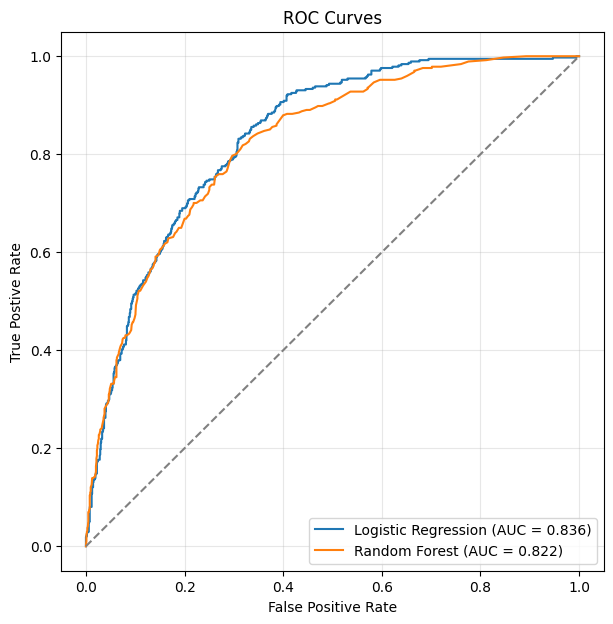

In [92]:
models = {
    'Logistic Regression': lr,
    'Random Forest': rf,
}

plt.figure(figsize=(7,7))

for name, m in models.items():
  probs = m.predict_proba(X_test_transformed)[:,1]
  fpr, tpr, _ = roc_curve(Y_test_encoded, probs)
  auc = roc_auc_score(Y_test_encoded, probs)
  plt.plot(fpr, tpr, label = f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], linestyle = '--', color = 'gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Postive Rate')
plt.title('ROC Curves')
plt.legend()
plt.grid(alpha = 0.3)
plt.show()

Hyper Parameter tuning through **Optuna**

In [94]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 19.8 MB/s eta 0:00:00


In [95]:
import optuna
from sklearn.model_selection import cross_val_score

def objective(trial):

  classifier_name = trial.suggest_categorical(
      "classifier", ["LogisticRegression", "RandomForest", "SVM"]
  )


  if classifier_name == "LogisticRegression":
    C = trial.suggest_float("C", 1e-4, 1e2, log = True)
    penalty = trial.suggest_categorical("penalty", ["l1", "l2"])
    solver = "liblinear"

    model = LogisticRegression(C = C, penalty = penalty, solver = solver)

  elif classifier_name == "RandomForest":
    n_estimators = trial.suggest_int("rf_n_estimators", 50, 500)
    max_depth = trial.suggest_int("rf_max_depth", 2, 32)
    min_samples_split = trial.suggest_int("rf_min_sample_split", 2, 20)

    model = RandomForestClassifier(
        n_estimators = n_estimators,
        max_depth = max_depth,
        min_samples_split = min_samples_split,
        n_jobs = -1
    )

  else:
    C = trial.suggest_float("C", 1e-3, 1e3, log = True)
    kernel = trial.suggest_categorical("kernel", ["rbf", "linear"])
    gamma = trial.suggest_categorical("gamma", ["scale", "auto"])
    model = SVC(C=C, kernel=kernel, gamma = gamma, random_state = 42)

  score = cross_val_score(model, X_train_transformed, Y_train_encoded, cv = 5, scoring = "accuracy").mean()
  return score

study = optuna.create_study(direction = "maximize")
study.optimize(objective, n_trials = 100)


[I 2026-07-14 20:41:46,361] A new study created in memory with name: no-name-306daf5a-b3da-4ba5-8391-0fd97a0263b2
[I 2026-07-14 20:42:03,462] Trial 0 finished with value: 0.7965889730670244 and parameters: {'classifier': 'RandomForest', 'rf_n_estimators': 295, 'rf_max_depth': 32, 'rf_min_sample_split': 20}. Best is trial 0 with value: 0.7965889730670244.
[I 2026-07-14 20:42:11,483] Trial 1 finished with value: 0.8044014115028976 and parameters: {'classifier': 'LogisticRegression', 'C': 8.355838375156548, 'penalty': 'l1'}. Best is trial 1 with value: 0.8044014115028976.
[I 2026-07-14 20:42:11,587] Trial 2 finished with value: 0.7346467539058252 and parameters: {'classifier': 'LogisticRegression', 'C': 0.00025158835960149503, 'penalty': 'l1'}. Best is trial 1 with value: 0.8044014115028976.
[I 2026-07-14 20:42:18,034] Trial 3 finished with value: 0.7953495739171411 and parameters: {'classifier': 'SVM', 'C': 1.0101499665459992, 'kernel': 'linear', 'gamma': 'scale'}. Best is trial 1 with v

In [96]:
# Printing Best model
print("Best overall model:", study.best_params["classifier"])
print("Best params:", study.best_params)
print("Best CV accuracy: " , study.best_value)

Best overall model: LogisticRegression
Best params: {'classifier': 'LogisticRegression', 'C': 32.59346126308893, 'penalty': 'l2'}
Best CV accuracy:  0.806353654288961


In [118]:
print(data['tenure'].unique())

['0-1 year' '2-3 year' '3-4 year' '1-2 year' '5-6 year' '4-5 year']


**Ready to Deploy**

In [97]:
import joblib
print("joblib library imported.")

joblib library imported.


In [98]:
joblib.dump(transformer, 'column_transformer.joblib')
joblib.dump(le, 'label_encoder.joblib')
print("ColumnTransformer and LabelEncoder saved successfully.")

ColumnTransformer and LabelEncoder saved successfully.


In [103]:
best_params = study.best_params
best_classifier_name = best_params['classifier']

if best_classifier_name == "LogisticRegression":
    best_C = best_params['C']
    best_penalty = best_params['penalty']
    best_model = LogisticRegression(C=best_C, penalty=best_penalty, solver='liblinear', max_iter=1000)

elif best_classifier_name == "RandomForest":
    best_n_estimators = best_params['rf_n_estimators']
    best_max_depth = best_params['rf_max_depth']
    best_min_samples_split = best_params['rf_min_sample_split']
    best_model = RandomForestClassifier(n_estimators=best_n_estimators, max_depth=best_max_depth, min_samples_split=best_min_samples_split, random_state=42, n_jobs=-1)

else: # SVM
    best_C = best_params['C']
    best_kernel = best_params['kernel']
    best_gamma = best_params['gamma']
    best_model = SVC(C=best_C, kernel=best_kernel, gamma=best_gamma, random_state=42, probability=True) # probability=True needed for ROC curve later if SVM is best

best_model.fit(X_train_transformed, Y_train_encoded)

joblib.dump(best_model, 'best_model.joblib')
print(f"Best model ({best_classifier_name}) trained and saved successfully.")


Best model (LogisticRegression) trained and saved successfully.


In [104]:
loaded_transformer = joblib.load('column_transformer.joblib')
loaded_label_encoder = joblib.load('label_encoder.joblib')

print("Preprocessing tools (ColumnTransformer and LabelEncoder) loaded successfully.")

Preprocessing tools (ColumnTransformer and LabelEncoder) loaded successfully.


In [105]:
loaded_model = joblib.load('best_model.joblib')

print("Best model loaded successfully.")

Best model loaded successfully.


In [114]:
import joblib

# 1. Load the saved objects (happens once when app starts)
loaded_model = joblib.load('best_model.joblib')
loaded_transformer = joblib.load('column_transformer.joblib')
loaded_label_encoder = joblib.load('label_encoder.joblib')

print(loaded_label_encoder.classes_)

['No' 'Yes']


In [111]:
import joblib

# 1. Load the saved objects (happens once when app starts)
loaded_model = joblib.load('best_model.joblib')
loaded_transformer = joblib.load('column_transformer.joblib')
loaded_label_encoder = joblib.load('label_encoder.joblib')

# 2. User enters raw values via sliders/dropdowns
tenure_input_raw = 12 # Renamed to avoid conflict after cutting
monthly_charges_input = 70.0
contract_input = "Month-to-month"
gender_input = "Male"
senior_citizen_input = 0 # 0 for No, 1 for Yes
partner_input = "Yes"
dependents_input = "No"
phone_service_input = "Yes"
multiple_lines_input = "No"
internet_service_input = "DSL"
online_security_input = "No"
online_backup_input = "Yes"
device_protection_input = "No"
tech_support_input = "No"
streaming_tv_input = "No"
streaming_movies_input = "No"
paperless_billing_input = "Yes"
payment_method_input = "Electronic check"
total_charges_input = 840.0 # Example total charges

# Re-apply the same tenure binning logic
bin_edges = [-1, 12, 24, 36, 48, 60, 72, np.inf]
bins_label = ['0-1 year', '1-2 year', '2-3 year', '3-4 year', '4-5 year', '5-6 year', '6+ years']

tenure_input_processed = pd.cut([tenure_input_raw], bins=bin_edges, labels=bins_label)[0]

# 3. Build a dataframe matching your ORIGINAL raw data structure (X_train)
# Ensure all columns from X_train are present, even if with dummy values for this example
input_data = {
    'gender': [gender_input],
    'SeniorCitizen': [senior_citizen_input],
    'Partner': [partner_input],
    'Dependents': [dependents_input],
    'tenure': [tenure_input_processed], # Use the processed tenure input
    'PhoneService': [phone_service_input],
    'MultipleLines': [multiple_lines_input],
    'InternetService': [internet_service_input],
    'OnlineSecurity': [online_security_input],
    'OnlineBackup': [online_backup_input],
    'DeviceProtection': [device_protection_input],
    'TechSupport': [tech_support_input],
    'StreamingTV': [streaming_tv_input],
    'StreamingMovies': [streaming_movies_input],
    'Contract': [contract_input],
    'PaperlessBilling': [paperless_billing_input],
    'PaymentMethod': [payment_method_input],
    'MonthlyCharges': [monthly_charges_input],
    'TotalCharges': [total_charges_input]
}

# Create the DataFrame with the specified column order (based on X_train.columns)
# Using X_train.columns for a robust column order. If X_train is not available,
# one would need to reconstruct the column order from the original data.
# For now, let's assume `data` dataframe still holds the column order before dropping 'Churn'
X_train_columns = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
                   'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
                   'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
                   'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
                   'MonthlyCharges', 'TotalCharges']

input_df = pd.DataFrame(input_data, columns=X_train_columns)

# 4. Apply the SAME preprocessing as training using the loaded_transformer
# The transformer handles both OneHotEncoding and StandardScaler
input_transformed = loaded_transformer.transform(input_df)

# 5. Predict
prob = loaded_model.predict_proba(input_transformed)[:, 1][0]
predicted_label_encoded = loaded_model.predict(input_transformed)[0]
predicted_label = loaded_label_encoder.inverse_transform([predicted_label_encoded])[0]

print(f"Predicted churn probability: {prob:.4f}")
print(f"Predicted churn status: {predicted_label}")

Predicted churn probability: 0.1839
Predicted churn status: No
